In [ ]:
# Paramdeep Choudhary
# cu24250162


Libraries imported successfully!
Upload TWO similar images for SIFT matching.


Saving image.jpg to image (1).jpg
Saving images1.jpeg to images1.jpeg
Image 1: image (1).jpg
Image 2: images1.jpeg
Images loaded successfully!
Image 1 size: (853, 1280)
Image 2 size: (148, 223)


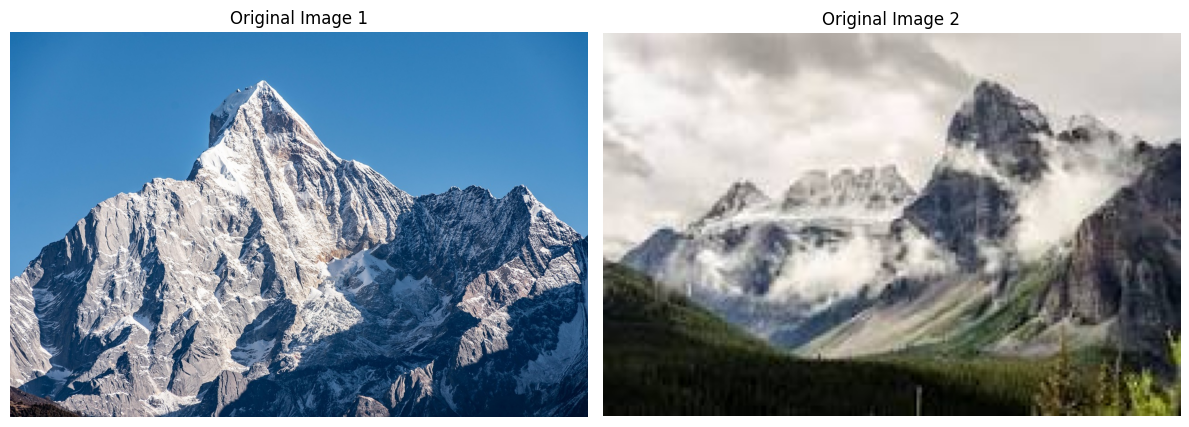


SIFT RESULTS
Image 1 keypoints: 8333
Image 2 keypoints: 297


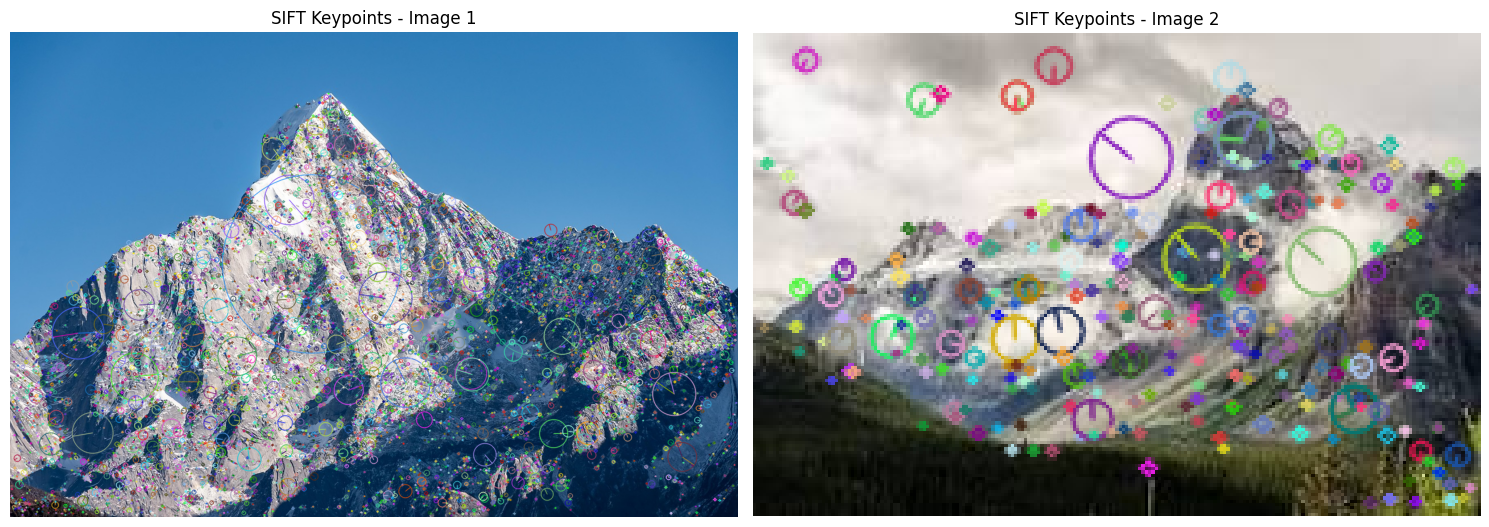


HOG RESULTS
Image 1 HOG feature length: 34596
Image 2 HOG feature length: 34596


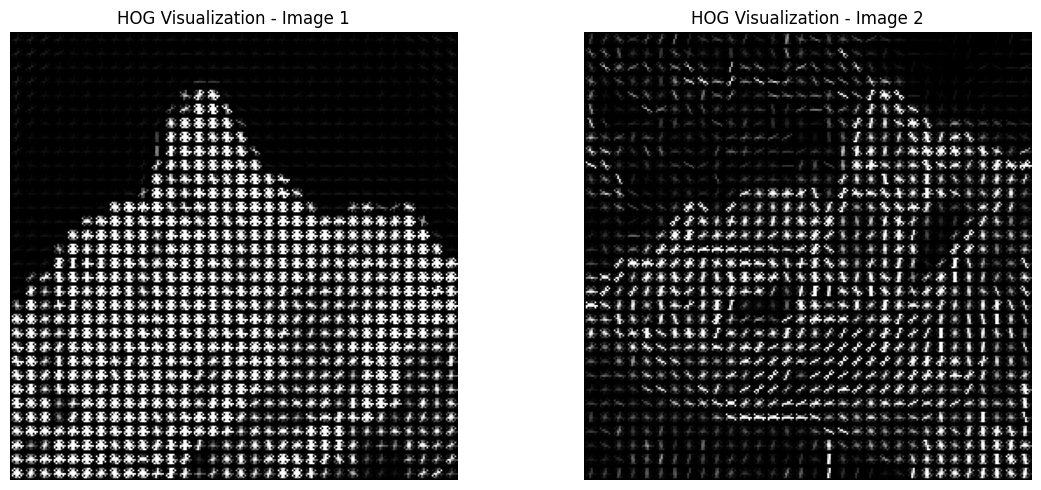


SIFT MATCHING RESULTS
Total matches: 8333
Good matches: 49


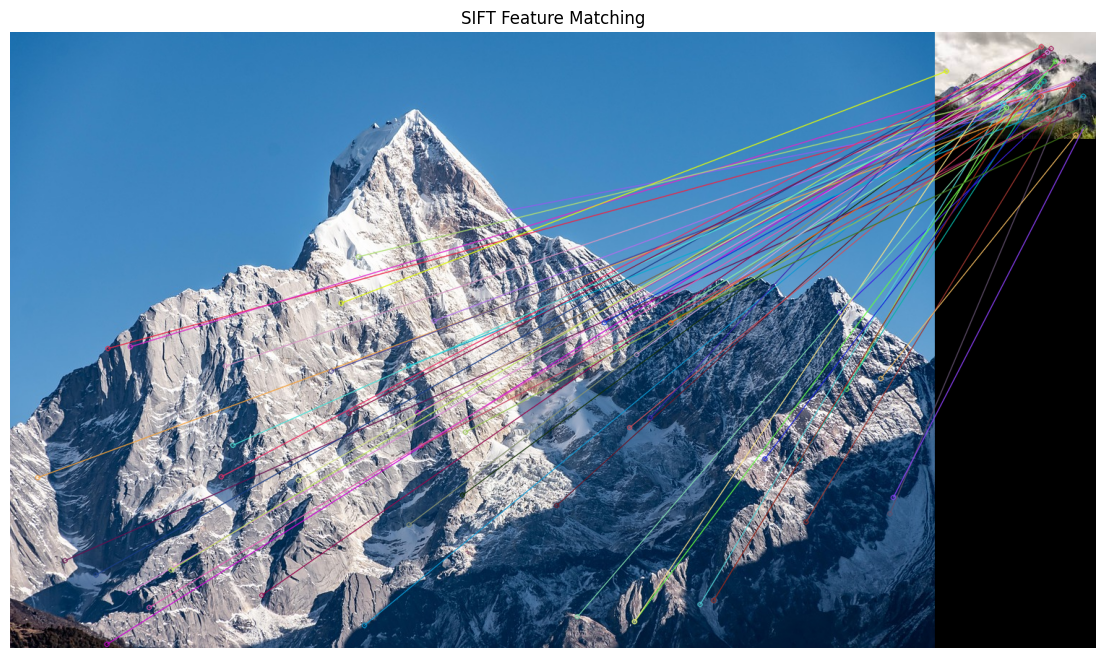


                 SIFT vs HOG COMPARISON

SIFT:
- Detects local keypoints and extracts descriptors.
- More robust to scale and rotation changes.
- Useful for image matching and object recognition.
- Computationally more expensive than simple gradient features.

HOG:
- Describes local gradient directions.
- Mainly captures shape and edge information.
- Computationally simpler than SIFT.
- Commonly used for object detection and shape recognition.


All output images saved successfully!

                    OBSERVATIONS

1. SIFT detects important local keypoints in an image.

2. SIFT descriptors are robust to scale and rotation changes.

3. SIFT is useful for image matching and object recognition.

4. HOG represents the distribution of gradient directions
   in local image regions.

5. HOG is effective for detecting object shape and edges.

6. SIFT generally provides stronger local feature matching.

7. HOG is computationally simpler and useful for
   object detection tasks.

8. SIFT can 

In [ ]:
# ============================================================
# EXPERIMENT NO. 5
# FEATURE EXTRACTION AND IMAGE ANALYSIS USING SIFT AND HOG
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from skimage.feature import hog
from skimage import exposure

print("Libraries imported successfully!")


# ============================================================
# 1. UPLOAD IMAGES
# ============================================================

print("Upload TWO similar images for SIFT matching.")
uploaded = files.upload()

file_names = list(uploaded.keys())

if len(file_names) < 2:
    raise Exception("Please upload at least TWO images.")

image1_name = file_names[0]
image2_name = file_names[1]

print("Image 1:", image1_name)
print("Image 2:", image2_name)


# ============================================================
# 2. LOAD IMAGES
# ============================================================

image1 = cv2.imread(image1_name)
image2 = cv2.imread(image2_name)

if image1 is None or image2 is None:
    raise Exception("One or both images could not be loaded.")

# Convert BGR to RGB for displaying
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

print("Images loaded successfully!")
print("Image 1 size:", gray1.shape)
print("Image 2 size:", gray2.shape)


# ============================================================
# 3. DISPLAY ORIGINAL IMAGES
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1_rgb)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2_rgb)
plt.title("Original Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 4. SIFT FEATURE EXTRACTION
# ============================================================

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

print("\nSIFT RESULTS")
print("Image 1 keypoints:", len(keypoints1))
print("Image 2 keypoints:", len(keypoints2))

if descriptors1 is None or descriptors2 is None:
    raise Exception("SIFT could not find enough features in the images.")


# ============================================================
# 5. VISUALIZE SIFT KEYPOINTS
# ============================================================

sift_image1 = cv2.drawKeypoints(
    image1_rgb,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

sift_image2 = cv2.drawKeypoints(
    image2_rgb,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(sift_image1)
plt.title("SIFT Keypoints - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sift_image2)
plt.title("SIFT Keypoints - Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. HOG FEATURE EXTRACTION
# ============================================================

# Resize images for consistent HOG processing
hog_size = (256, 256)

gray1_hog = cv2.resize(gray1, hog_size)
gray2_hog = cv2.resize(gray2, hog_size)

# HOG parameters
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)

# Extract HOG features
hog_features1, hog_image1 = hog(
    gray1_hog,
    orientations=orientations,
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block,
    block_norm="L2-Hys",
    visualize=True
)

hog_features2, hog_image2 = hog(
    gray2_hog,
    orientations=orientations,
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block,
    block_norm="L2-Hys",
    visualize=True
)

# Improve HOG visualization
hog_image1 = exposure.rescale_intensity(
    hog_image1,
    in_range=(0, 10)
)

hog_image2 = exposure.rescale_intensity(
    hog_image2,
    in_range=(0, 10)
)

print("\nHOG RESULTS")
print("Image 1 HOG feature length:", len(hog_features1))
print("Image 2 HOG feature length:", len(hog_features2))


# ============================================================
# 7. DISPLAY HOG FEATURES
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(hog_image1, cmap="gray")
plt.title("HOG Visualization - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image2, cmap="gray")
plt.title("HOG Visualization - Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 8. SIFT IMAGE MATCHING
# ============================================================

# Create BFMatcher
bf = cv2.BFMatcher()

# Match descriptors using KNN
matches = bf.knnMatch(
    descriptors1,
    descriptors2,
    k=2
)

# Lowe's ratio test
good_matches = []

for match_pair in matches:

    if len(match_pair) == 2:

        m, n = match_pair

        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

print("\nSIFT MATCHING RESULTS")
print("Total matches:", len(matches))
print("Good matches:", len(good_matches))


# ============================================================
# 9. DISPLAY SIFT MATCHING
# ============================================================

# Sort matches according to distance
good_matches = sorted(
    good_matches,
    key=lambda x: x.distance
)

# Display maximum 50 good matches
display_matches = good_matches[:50]

matched_image = cv2.drawMatches(
    image1_rgb,
    keypoints1,
    image2_rgb,
    keypoints2,
    display_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18, 8))
plt.imshow(matched_image)
plt.title("SIFT Feature Matching")
plt.axis("off")
plt.show()


# ============================================================
# 10. COMPARE SIFT AND HOG
# ============================================================

print("""
============================================================
                 SIFT vs HOG COMPARISON
============================================================

SIFT:
- Detects local keypoints and extracts descriptors.
- More robust to scale and rotation changes.
- Useful for image matching and object recognition.
- Computationally more expensive than simple gradient features.

HOG:
- Describes local gradient directions.
- Mainly captures shape and edge information.
- Computationally simpler than SIFT.
- Commonly used for object detection and shape recognition.

============================================================
""")


# ============================================================
# 11. SAVE OUTPUTS
# ============================================================

cv2.imwrite(
    "sift_keypoints_image1.jpg",
    cv2.cvtColor(sift_image1, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "sift_keypoints_image2.jpg",
    cv2.cvtColor(sift_image2, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "hog_visualization_image1.jpg",
    np.uint8(hog_image1 * 255)
)

cv2.imwrite(
    "hog_visualization_image2.jpg",
    np.uint8(hog_image2 * 255)
)

cv2.imwrite(
    "sift_feature_matching.jpg",
    cv2.cvtColor(matched_image, cv2.COLOR_RGB2BGR)
)

print("All output images saved successfully!")


# ============================================================
# 12. OBSERVATIONS
# ============================================================

print("""
============================================================
                    OBSERVATIONS
============================================================

1. SIFT detects important local keypoints in an image.

2. SIFT descriptors are robust to scale and rotation changes.

3. SIFT is useful for image matching and object recognition.

4. HOG represents the distribution of gradient directions
   in local image regions.

5. HOG is effective for detecting object shape and edges.

6. SIFT generally provides stronger local feature matching.

7. HOG is computationally simpler and useful for
   object detection tasks.

8. SIFT can handle changes in scale and rotation better
   than HOG.

9. HOG is highly useful when shape and edge information
   are important.

10. Both SIFT and HOG convert raw image information into
    useful feature representations for computer vision.

============================================================
              EXPERIMENT COMPLETED SUCCESSFULLY
============================================================
""")

In [ ]:
// 1. What is feature extraction, and why is it important in computer vision?
//
// Answer:
// Feature extraction converts an image into useful information such as
// edges, shapes, and keypoints. It helps in recognition and classification.

// 2. Explain the working principle of Scale-Invariant Feature Transform (SIFT).
//
// Answer:
// SIFT detects important keypoints at different scales and orientations
// and generates descriptors for matching these features.

// 3. What are keypoints and feature descriptors in image analysis?
//
// Answer:
// Keypoints are important locations in an image.
// Feature descriptors are numerical representations of the regions
// around those keypoints.

// 4. Explain the concept of Histogram of Oriented Gradients (HOG)
// and its significance.
//
// Answer:
// HOG describes the direction and strength of image gradients.
// It is useful for representing object shape and detecting objects.

// 5. Compare SIFT and HOG based on robustness, computational complexity,
// and practical applications.
//
// Answer:
// SIFT is more robust to scale and rotation and is useful for image matching.
// HOG is simpler and is mainly useful for object detection and shape analysis.

// 6. Why is SIFT considered invariant to scale and rotation?
//
// Answer:
// SIFT detects features at multiple scales and assigns an orientation
// to keypoints, allowing features to be matched despite scale and
// rotation changes.

// 7. Mention three real-world applications where HOG descriptors
// are commonly used.
//
// Answer:
// 1. Pedestrian detection
// 2. Vehicle detection
// 3. Object recognition

// 8. Why is feature extraction performed before image classification
// or object detection?
//
// Answer:
// It reduces raw image information into meaningful features,
// making classification and detection easier and more efficient.

// 9. What are the advantages and limitations of handcrafted feature
// descriptors compared to deep learning-based feature extraction?
//
// Answer:
// Handcrafted features are simple, interpretable, and need less data.
// However, they may perform poorly on complex images compared with
// deep learning features.

// 10. How do feature extraction techniques contribute to image matching,
// face recognition, and object detection systems?
//
// Answer:
// They provide important image features that help systems compare,
// recognize, classify, and detect objects accurately.